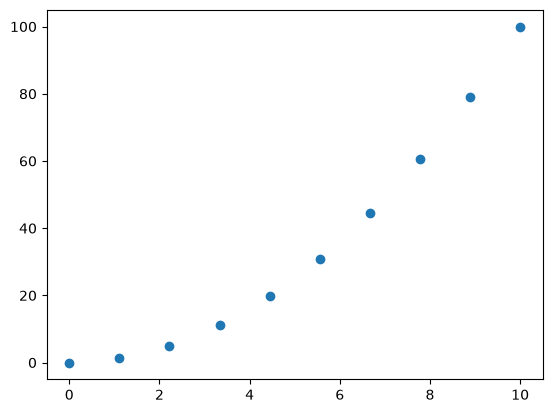

In [1]:
# ============================================================
# Interpolate
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

x= np.linspace(0,10,10)
y= x**2
plt.scatter(x,y)


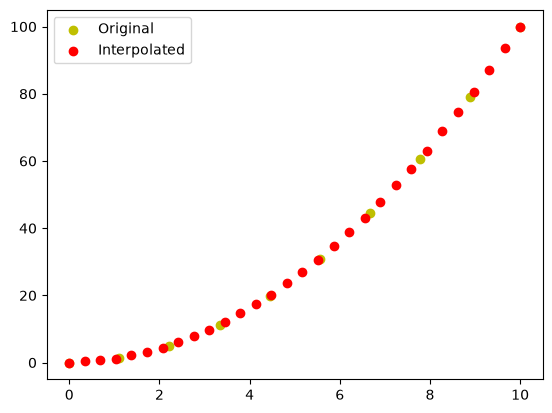

In [5]:
from scipy.interpolate import interp1d

f = interp1d(x, y, kind='linear')
new_x= np.linspace(0, 10, 30)
result= f(new_x)
plt.scatter(x, y, c='y')
plt.scatter(new_x, result, c='r')
plt.legend(['Original', 'Interpolated'])
plt.show()

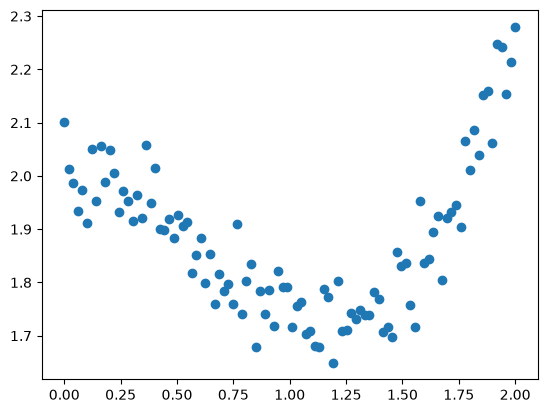

In [6]:
# ============================================================
# optimization
# ============================================================

x = np.linspace(0, 2, 100)
y = 1/3 * x**3 - 3/5 * x**2 + 2 + np.random.randn(x.shape[0]) / 20
plt.scatter(x, y)






 parametre a,b,c d et matrice de covariance : (array([ 0.31979417, -0.551394  , -0.03997451,  2.01333477]), array([[ 0.00107268, -0.00321805,  0.00256152, -0.00041616],
       [-0.00321805,  0.00993532, -0.00824693,  0.00143403],
       [ 0.00256152, -0.00824693,  0.00731801, -0.00144136],
       [-0.00041616,  0.00143403, -0.00144136,  0.00038639]]))


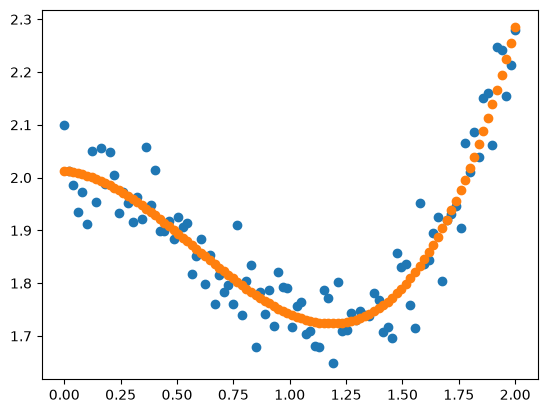

In [9]:
def f(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

from scipy import optimize
print(f' parametre a,b,c d et matrice de covariance : {optimize.curve_fit(f, x, y)}')
param, param_cov=optimize.curve_fit(f, x, y)
plt.scatter (x,y)
plt.scatter(x, f(x,param[0],param[1],param[2],param[3]))

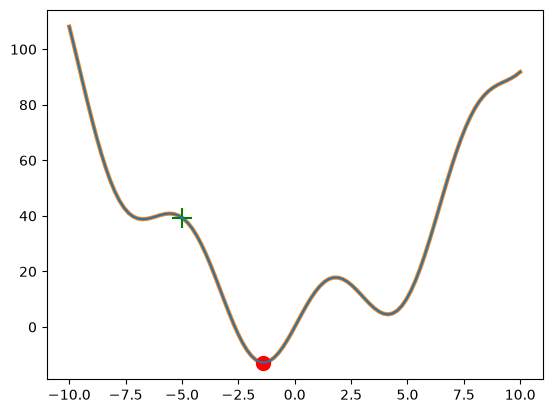

In [27]:
# ============================================================
# Minimize
# ============================================================
def f(x):
    return x**2 + 15*np.sin(x)

x = np.linspace(-10, 10, 100)
plt.plot(x, f(x))

x0 = -5
result = optimize.minimize(f, x0=x0).x

plt.plot(x, f(x), lw=3, zorder=-1)
plt.scatter(result, f(result), s=100, c='r', zorder=1)
plt.scatter(x0, f(x0), s=200, marker='+', c='g', zorder=1)

plt.show()


Point de départ : [0. 0.]
Dimension de x0 : (2,)
Affichage du minimum :
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -2.236067977499789
        x: [-4.636e-01 -3.000e+00]
      nit: 6
      jac: [ 8.882e-08  8.944e-01]
     nfev: 30
     njev: 10
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
Position du minimum : [-0.46364758 -3.        ]
Valeur minimale : -2.236067977499789


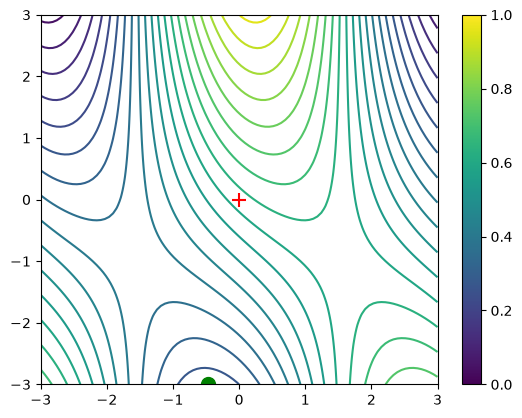

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize


# Fonction à deux variables
def f(x):
    return np.sin(x[0]) + np.cos(x[0]) + x[1] * np.cos(x[0])


# Création de la grille
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x, y)


# Affichage des courbes de niveau
plt.contour(X, Y, f(np.array([X, Y])), 20)

# Point de départ
x0 = np.zeros(2)

print("Point de départ :", x0)
print("Dimension de x0 :", x0.shape)


# Recherche du minimum
result = optimize.minimize(
    f,
    x0=x0,
    bounds=[(-3, 3), (-3, 3)],
    method='L-BFGS-B'
)


# Affichage du résultat
print("Affichage du minimum :")
print(result)

print("Position du minimum :", result.x)
print("Valeur minimale :", result.fun)


# Afficher le point de départ en rouge
plt.scatter(
    x0[0],
    x0[1],
    marker='+',
    c='r',
    s=100
)


# Afficher le minimum en vert
plt.scatter(
    result.x[0],
    result.x[1],
    c='g',
    s=100
)

plt.colorbar()
plt.show()



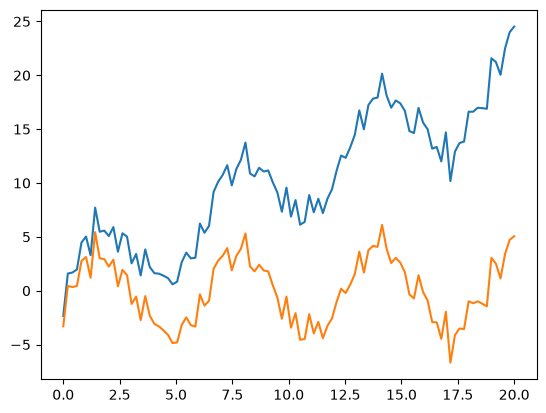

In [42]:
# ============================================================
# Signal processing
# ============================================================


x = np.linspace(0, 20, 100)
y = x + 4*np.sin(x) + np.random.randn(x.shape[0])


from scipy import signal

new_y = signal.detrend(y)

plt.plot(x, y)
plt.plot(x, new_y)

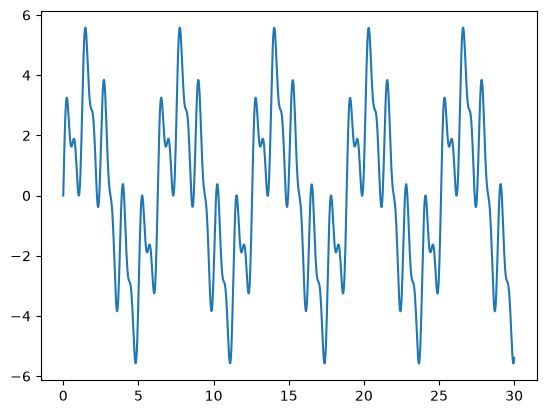

In [ ]:
# ============================================================
# FFT
# ============================================================
x = np.linspace(0, 30, 1000)
y = 3*np.sin(x) + 2*np.sin(5*x) + np.sin(10*x)
plt.plot(x, y)




c:\miniconda\envs\python314\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\miniconda\envs\python314\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


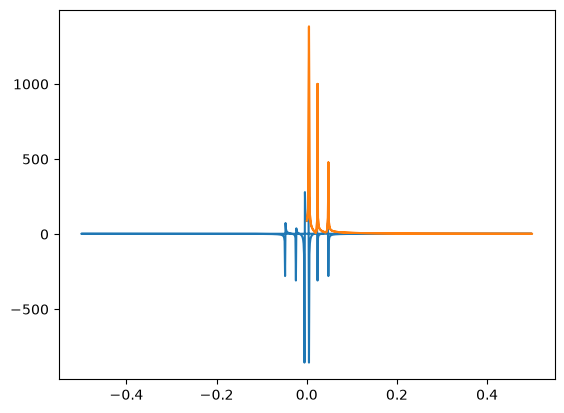

In [ ]:
from scipy import fftpack

fourier = fftpack.fft(y)
power= np.abs(fourier)
frequences = fftpack.fftfreq(y.size)

plt.plot(frequences, fourier)
plt.plot(np.abs(frequences), power)

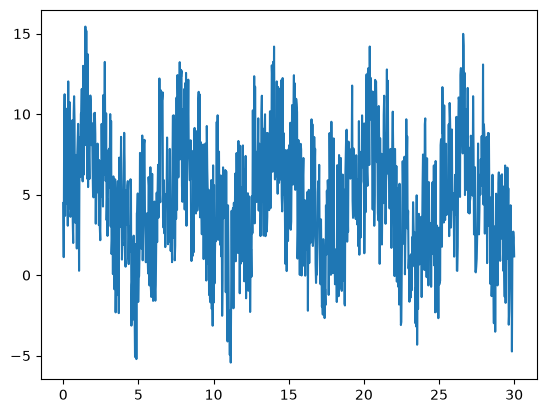

In [49]:
# ============================================================
# Nettoyage signal via FFT inverse 
# ============================================================

x = np.linspace(0, 30, 1000)
y = 3*np.sin(x) + 2*np.sin(5*x) + np.sin(10*x) + np.random.random(x.shape[0])*10
plt.plot(x, y)


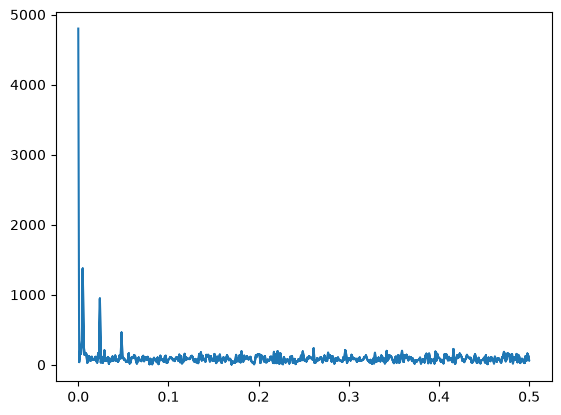

In [50]:
fourier = fftpack.fft(y)
power= np.abs(fourier)
frequences = fftpack.fftfreq(y.size)
freq =np.abs(frequences)
plt.plot(freq,power)

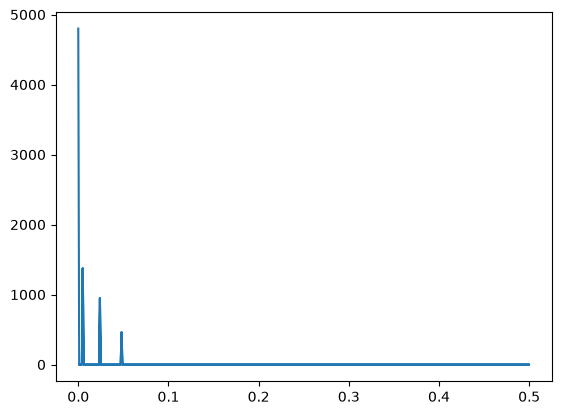

In [53]:
fourier[power <400] = 0
plt.plot(freq,np.abs(fourier))

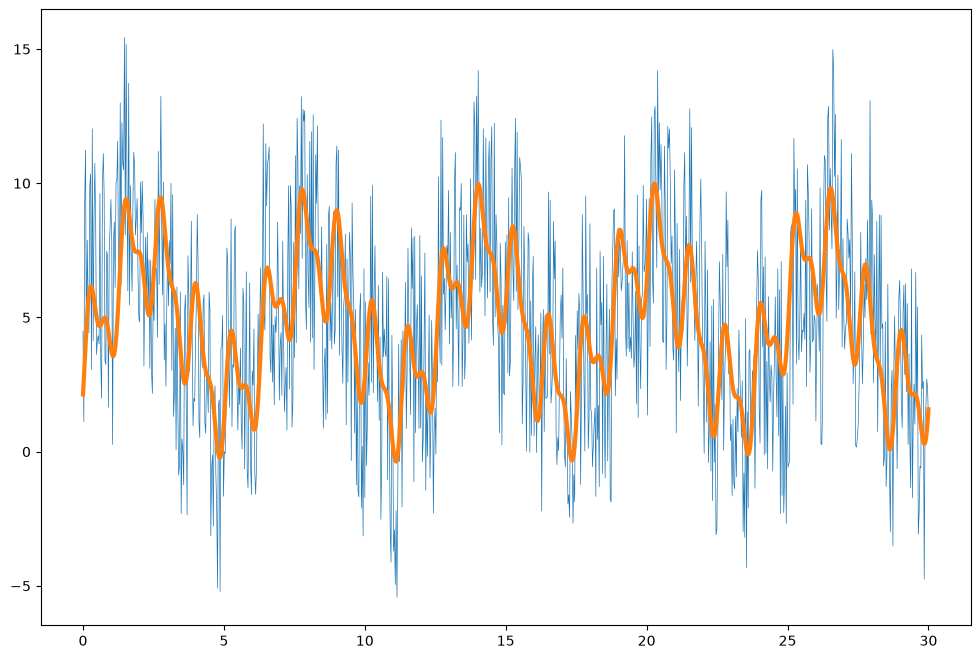

In [56]:
filtered_signal= fftpack.ifft(fourier)
plt.figure(figsize=(12,8))
plt.plot(x,y, lw=0.5)
plt.plot(x,filtered_signal,lw=3)


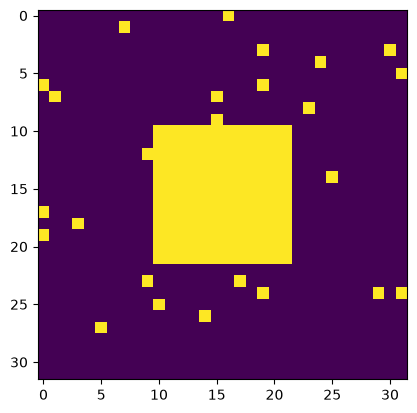

In [ ]:
# ============================================================
# Traitement d'image ndimage
# ============================================================

from scipy import ndimage

np.random.seed(0)

X = np.zeros((32, 32))
X[10:-10, 10:-10] = 1
X[np.random.randint(0, 32, 30), np.random.randint(0, 32, 30)] = 1

plt.imshow(X)






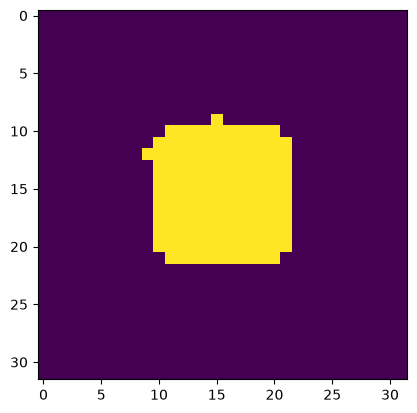

In [61]:
# Ouverture morphologique : supprime les petits éléments/bruits
open_x = ndimage.binary_opening(X)

# Afficher l'image après l'ouverture morphologique
plt.imshow(open_x)

(307, 282)

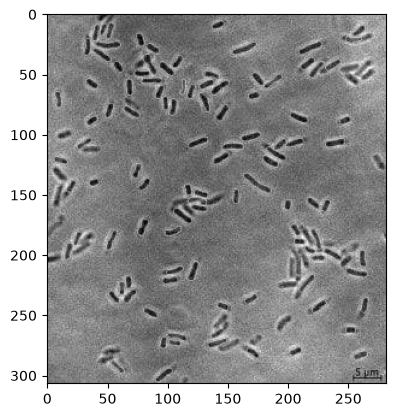

In [79]:
# Charger l'image
image = plt.imread('bacteria.png')
image = image[:,:,0]
plt.imshow(image, cmap='gray')
image.shape



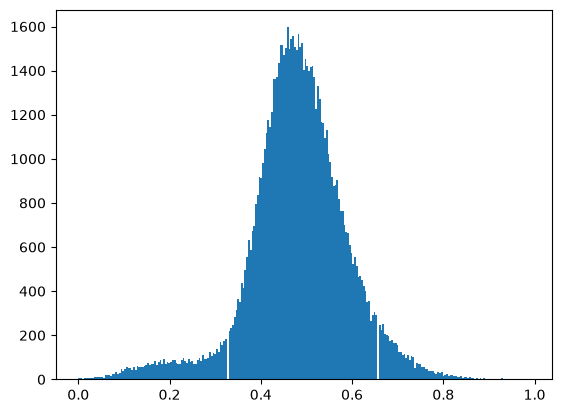

In [80]:
image_2= np.copy(image)
plt.hist(image_2.ravel(), bins=255)
plt.show()

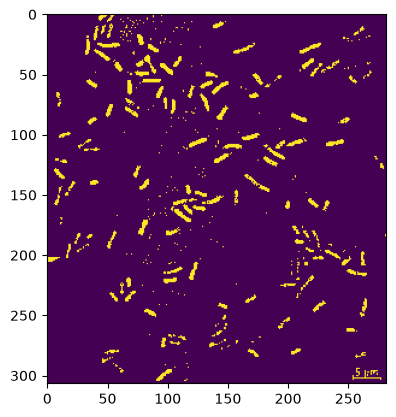

In [89]:
image=image<0.3
plt.imshow(image)


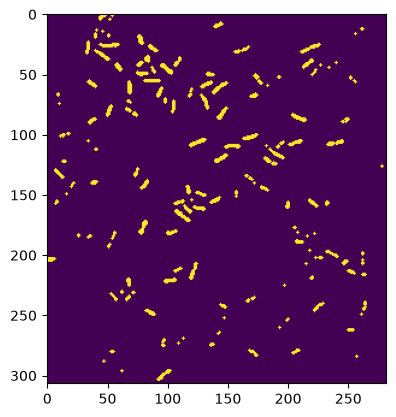

In [91]:
# Ouverture morphologique : supprime les petits éléments/bruits
open_x = ndimage.binary_opening(image)

# Afficher l'image après l'ouverture morphologique
plt.imshow(open_x)

152


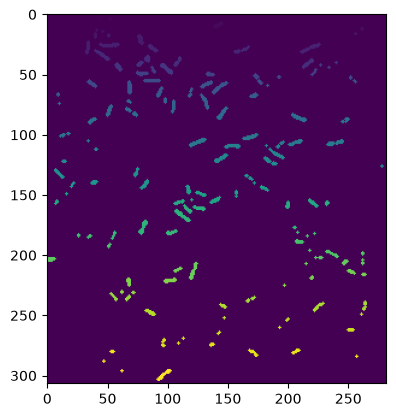

In [92]:
# Identifier les différentes régions/objets connectés dans l'image
label_image, n_labels = ndimage.label(open_x)

# Afficher le nombre de régions détectées
print(n_labels)

# Afficher l'image avec les régions étiquetées
plt.imshow(label_image)

[ 0. 24.  5.  5. 27.  8.  5.  5. 14.  5.  8. 34. 32. 53. 55. 31. 36. 45.
 26. 28. 36. 21.  5. 30. 47.  5. 17.  5. 16. 34. 24. 18.  8.  8. 31. 41.
 14.  8. 41. 36. 52.  5. 31. 21.  8. 24. 43. 14. 11. 32.  5. 34. 17. 44.
 16. 46. 26. 22.  8. 14. 44. 52.  5. 38. 47. 11. 43.  5. 10.  8. 42. 43.
 23. 11. 15.  5. 24. 30.  8. 11. 32. 20. 13.  5. 26. 22. 15. 26.  5. 32.
  5. 30. 11. 27. 20. 14. 27. 32. 53. 47.  8. 30. 18.  5.  5.  8. 11.  5.
 23. 11.  5. 31.  8. 16. 25. 12. 19. 48.  5. 20. 21. 11. 10. 24. 36.  5.
  8.  8. 20. 16. 11. 10. 21. 31. 18. 31.  5.  5.  8.  5. 17.  8.  5. 20.
  5. 13. 25. 21. 11.  5.  5.  5.]


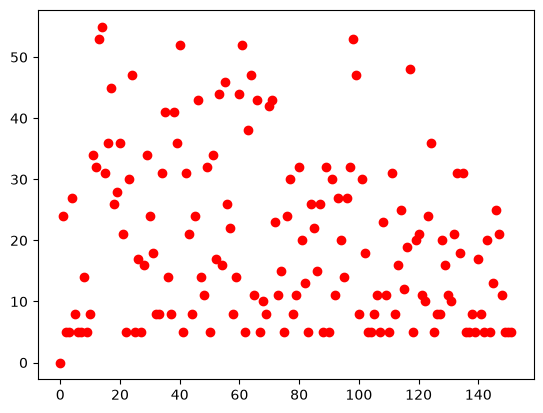

In [96]:
# Calculer la taille de chaque région détectée
sizes = ndimage.sum(open_x, label_image, range(n_labels))
print(sizes)
plt.scatter(range(n_labels), sizes, c='red')